# 06 — Conditional Flow Matching (All Three Pipelines)

This notebook implements **conditional flow matching** across all three compression strategies,
mirroring the unconditional pipelines from notebooks 02–04:

1. **Conditional FM-PCA**: PCA (20-dim) + conditional flow matching
2. **Conditional FM-AE**: Autoencoder (20-dim) + conditional flow matching
3. **Conditional FM-Gene**: Direct gene space (2000-dim) + conditional flow matching

Each variant conditions generation on **cluster labels** (Leiden clustering, 9 clusters),
allowing generation of specific cell types on demand. This is analogous to how cscGAN
conditions on cluster labels, enabling a fair head-to-head comparison.

**Recap of why three pipelines:**
- **PCA** = linear compression. Captures directions of maximum variance. Simple, fast.
- **AE** = nonlinear compression. Neural network learns to compress/decompress. Can capture
  nonlinear structure that PCA misses.
- **Gene** = no compression. Train directly in the full 2000-dim gene space. Hardest but
  preserves all information.

In [ ]:
import sys, os
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.insert(0, PROJECT_ROOT)
os.chdir(PROJECT_ROOT)

import numpy as np
import torch
import joblib
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.decomposition import PCA

import config as cfg
from src.preprocess import set_seed, load_processed
from src.models_flow import train_conditional_flow_matching
from src.models_ae import AutoEncoder, encode_np
from src.metrics import distribution_metrics, compute_mmd, memorization_check
from src.metrics import plot_umap_overlay, plot_training_curves

set_seed()
print(f"Device: {cfg.DEVICE}")

Device: cuda


## 1. Load Data + Cluster Labels

In [ ]:
data = load_processed()
X_all = data["X_all"]
X_train_s = data["X_train_s"]
X_val_s = data["X_val_s"]
X_all_s = data["X_all_s"]
scaler = data["scaler"]
hvg_names = data["hvg_names"]

labels_all = np.load(os.path.join(cfg.DATA_DIR, "leiden_labels.npy"))
train_idx = np.load(os.path.join(cfg.DATA_DIR, "train_idx.npy"))
val_idx = np.load(os.path.join(cfg.DATA_DIR, "val_idx.npy"))

labels_train = labels_all[train_idx]
n_classes = len(np.unique(labels_all))

cluster_counts = Counter(labels_all.tolist())
n_per_class = [cluster_counts.get(c, 0) for c in range(n_classes)]

print(f"Train: {X_train_s.shape}, Clusters: {n_classes}")
print(f"Cluster distribution: {dict(zip(*np.unique(labels_train, return_counts=True)))}")
print(f"Cells to generate per cluster: {n_per_class} (total {sum(n_per_class)})")

Train: (2110, 2000), Clusters: 9
Cluster distribution: {np.int64(0): np.int64(482), np.int64(1): np.int64(473), np.int64(2): np.int64(363), np.int64(3): np.int64(267), np.int64(4): np.int64(237), np.int64(5): np.int64(144), np.int64(6): np.int64(106), np.int64(7): np.int64(26), np.int64(8): np.int64(12)}
Cells to generate per cluster: [593, 580, 453, 345, 293, 181, 141, 34, 18] (total 2638)


---
## 2. Conditional FM-PCA (20-dim PCA space)

Same PCA as notebook 02 — compress 2000→20, train conditional flow matching in 20-dim,
then PCA inverse + inverse standardize back to gene expression space.

PCA latent shape: (2110, 20)
Training conditional FM in 20-dim PCA space with 9 classes...
  Epoch [   1/500] loss=10.7324
  Epoch [ 100/500] loss=3.2739
  Epoch [ 200/500] loss=2.9334
  Epoch [ 300/500] loss=2.8064
  Epoch [ 400/500] loss=2.1671
  Epoch [ 500/500] loss=2.2696


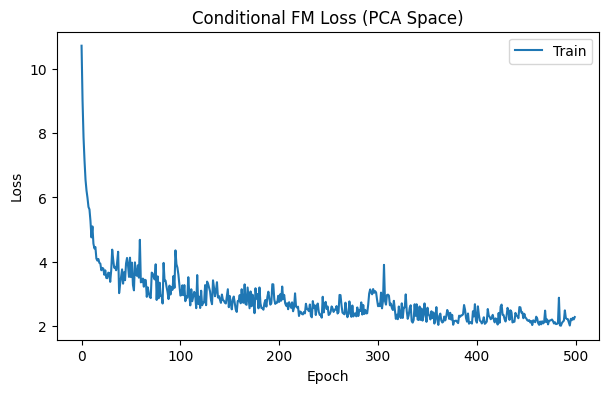

In [ ]:
# Load existing PCA model from notebook 02
pca = joblib.load(os.path.join(cfg.MODEL_DIR, "pca.joblib"))
Z_train_pca = pca.transform(X_train_s).astype(np.float32)
dim_pca = Z_train_pca.shape[1]

print(f"PCA latent shape: {Z_train_pca.shape}")
print(f"Training conditional FM in {dim_pca}-dim PCA space with {n_classes} classes...")

set_seed()
cond_flow_pca, loss_pca = train_conditional_flow_matching(
    Z_train=Z_train_pca,
    labels_train=labels_train,
    dim=dim_pca,
    n_classes=n_classes,
    device=cfg.DEVICE,
    hidden=cfg.CFM_HIDDEN,
    n_layers=cfg.CFM_LAYERS,
    lr=cfg.CFM_LR,
    batch_size=cfg.CFM_BATCH_SIZE,
    n_epochs=cfg.CFM_EPOCHS,
    print_every=100,
)

plot_training_curves(loss_pca, title="Conditional FM Loss (PCA Space)")
plt.show()

Cond FM-PCA: (2638, 2000), range [-1.32, 7.38]
  Mean MSE: 0.000099, Std MSE: 0.121793


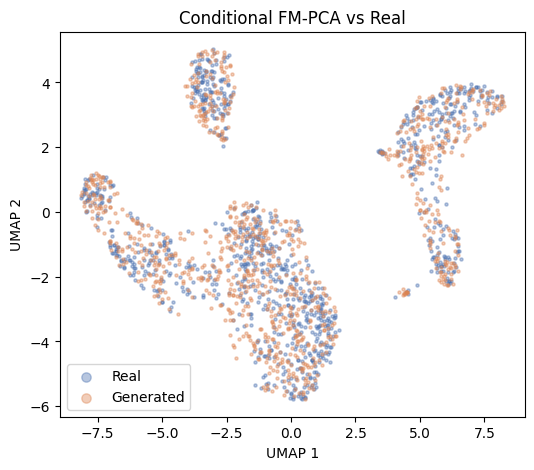

In [ ]:
# Generate
set_seed()
Z_gen_pca, labels_gen_pca = cond_flow_pca.sample(n_per_class, dim_pca, cfg.DEVICE)
X_gen_cond_pca = scaler.inverse_transform(pca.inverse_transform(Z_gen_pca)).astype(np.float32)
print(f"Cond FM-PCA: {X_gen_cond_pca.shape}, range [{X_gen_cond_pca.min():.2f}, {X_gen_cond_pca.max():.2f}]")

# Quick eval
m = distribution_metrics(X_all, X_gen_cond_pca)
print(f"  Mean MSE: {m['Mean MSE']:.6f}, Std MSE: {m['Std MSE']:.6f}")
plot_umap_overlay(X_all, X_gen_cond_pca, title="Conditional FM-PCA vs Real")
plt.show()

---
## 3. Conditional FM-AE (20-dim AE latent space)

Same autoencoder as notebook 03 — compress 2000→20 via trained encoder, train conditional
flow matching in 20-dim latent, then decode + inverse standardize back to gene space.

AE latent shape: (2110, 20)
Training conditional FM in 20-dim AE space with 9 classes...
  Epoch [   1/500] loss=1.7786
  Epoch [ 100/500] loss=0.7334
  Epoch [ 200/500] loss=0.6990
  Epoch [ 300/500] loss=0.6914
  Epoch [ 400/500] loss=0.6703
  Epoch [ 500/500] loss=0.6712


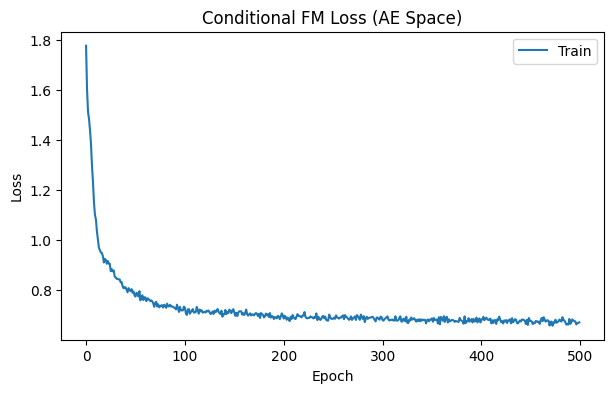

In [ ]:
# Load existing AE model from notebook 03
ae = AutoEncoder(input_dim=cfg.N_HVG, latent_dim=cfg.LATENT_DIM,
                 hidden_dims=cfg.AE_HIDDEN_DIMS, dropout=cfg.AE_DROPOUT)
ae.load_state_dict(torch.load(os.path.join(cfg.MODEL_DIR, "ae_model.pt"),
                               map_location=cfg.DEVICE))
ae.to(cfg.DEVICE)
ae.eval()

Z_train_ae = encode_np(ae, X_train_s, cfg.DEVICE)
dim_ae = Z_train_ae.shape[1]

print(f"AE latent shape: {Z_train_ae.shape}")
print(f"Training conditional FM in {dim_ae}-dim AE space with {n_classes} classes...")

set_seed()
cond_flow_ae, loss_ae = train_conditional_flow_matching(
    Z_train=Z_train_ae,
    labels_train=labels_train,
    dim=dim_ae,
    n_classes=n_classes,
    device=cfg.DEVICE,
    hidden=cfg.CFM_HIDDEN,
    n_layers=cfg.CFM_LAYERS,
    lr=cfg.CFM_LR,
    batch_size=cfg.CFM_BATCH_SIZE,
    n_epochs=cfg.CFM_EPOCHS,
    print_every=100,
)

plot_training_curves(loss_ae, title="Conditional FM Loss (AE Space)")
plt.show()

Cond FM-AE: (2638, 2000), range [-0.57, 6.98]
  Mean MSE: 0.000104, Std MSE: 0.126899


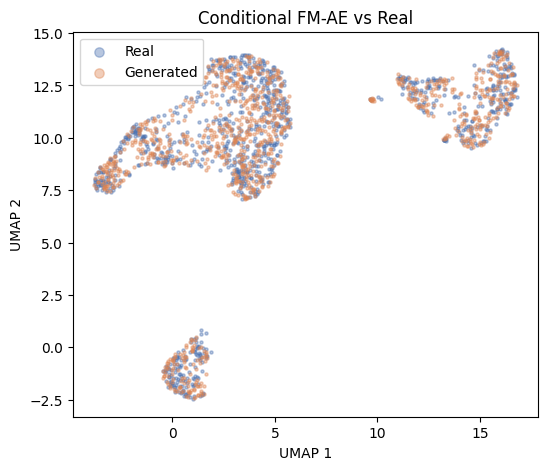

In [ ]:
# Generate
from src.models_ae import decode_np

set_seed()
Z_gen_ae, labels_gen_ae = cond_flow_ae.sample(n_per_class, dim_ae, cfg.DEVICE)
X_gen_cond_ae_s = decode_np(ae, Z_gen_ae, cfg.DEVICE)
X_gen_cond_ae = scaler.inverse_transform(X_gen_cond_ae_s).astype(np.float32)
print(f"Cond FM-AE: {X_gen_cond_ae.shape}, range [{X_gen_cond_ae.min():.2f}, {X_gen_cond_ae.max():.2f}]")

m = distribution_metrics(X_all, X_gen_cond_ae)
print(f"  Mean MSE: {m['Mean MSE']:.6f}, Std MSE: {m['Std MSE']:.6f}")
plot_umap_overlay(X_all, X_gen_cond_ae, title="Conditional FM-AE vs Real")
plt.show()

---
## 4. Conditional FM-Gene (2000-dim gene space)

No compression — train conditional flow matching directly in the 2000-dim standardized
gene space. Bigger network (hidden=1024, 6 layers) and longer training (800 epochs).

Training conditional FM in 2000-dim gene space with 9 classes...
(This takes longer — bigger network for 2000-dim space)
  Epoch [   1/800] loss=1.9971
  Epoch [ 100/800] loss=1.8889
  Epoch [ 200/800] loss=1.7180
  Epoch [ 300/800] loss=1.6103
  Epoch [ 400/800] loss=1.5437
  Epoch [ 500/800] loss=1.5286
  Epoch [ 600/800] loss=1.5174
  Epoch [ 700/800] loss=1.4972
  Epoch [ 800/800] loss=1.4714


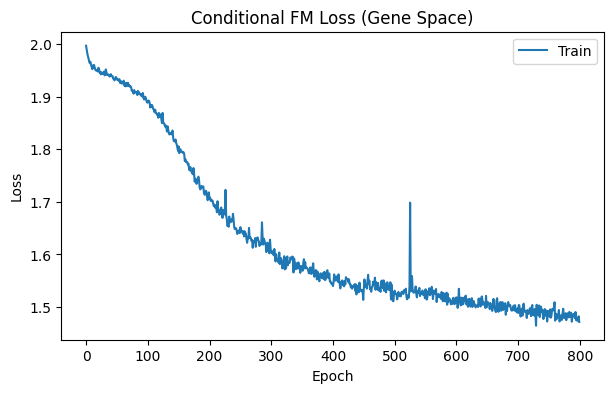

In [ ]:
dim_gene = X_train_s.shape[1]
print(f"Training conditional FM in {dim_gene}-dim gene space with {n_classes} classes...")
print("(This takes longer — bigger network for 2000-dim space)")

set_seed()
cond_flow_gene, loss_gene = train_conditional_flow_matching(
    Z_train=X_train_s,
    labels_train=labels_train,
    dim=dim_gene,
    n_classes=n_classes,
    device=cfg.DEVICE,
    hidden=cfg.FM_GENE_HIDDEN,
    n_layers=cfg.FM_GENE_LAYERS,
    lr=cfg.FM_GENE_LR,
    batch_size=cfg.FM_GENE_BATCH_SIZE,
    n_epochs=cfg.FM_GENE_EPOCHS,
    print_every=100,
)

plot_training_curves(loss_gene, title="Conditional FM Loss (Gene Space)")
plt.show()

Cond FM-Gene: (2638, 2000), range [-7.13, 11.86]
  Mean MSE: 0.000444, Std MSE: 0.006381


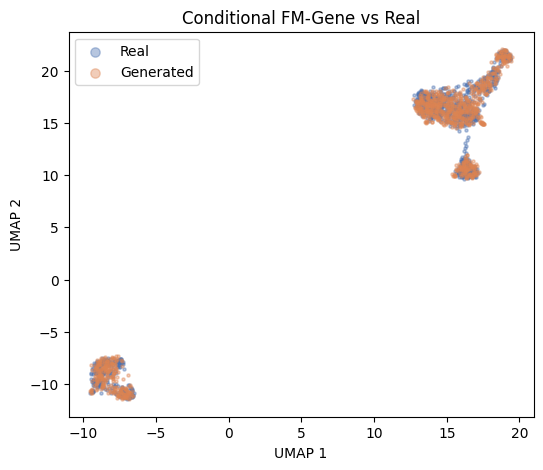

In [ ]:
# Generate
set_seed()
Z_gen_gene, labels_gen_gene = cond_flow_gene.sample(n_per_class, dim_gene, cfg.DEVICE)
X_gen_cond_gene = scaler.inverse_transform(Z_gen_gene).astype(np.float32)
print(f"Cond FM-Gene: {X_gen_cond_gene.shape}, range [{X_gen_cond_gene.min():.2f}, {X_gen_cond_gene.max():.2f}]")

m = distribution_metrics(X_all, X_gen_cond_gene)
print(f"  Mean MSE: {m['Mean MSE']:.6f}, Std MSE: {m['Std MSE']:.6f}")
plot_umap_overlay(X_all, X_gen_cond_gene, title="Conditional FM-Gene vs Real")
plt.show()

---
## 5. Comparison: All Three Conditional FM Variants

Compare the three conditional FM variants against each other and against the unconditional
FM results from notebook 05. Also compare cluster diversity (mode collapse check) with
cscGAN-exp6 from the scGAN project.

In [ ]:
# Helper
def avg_off_diag(M):
    n = M.shape[0]
    return np.mean([np.corrcoef(M[i], M[j])[0, 1] for i in range(n) for j in range(n) if i != j])

clusters = sorted(np.unique(labels_all))
real_means = np.array([X_all[labels_all == c].mean(axis=0) for c in clusters])

print("=" * 80)
print("CONDITIONAL FLOW MATCHING — COMPARISON")
print("=" * 80)

results = []
for name, X_gen, gen_labels in [
    ("Cond FM-PCA", X_gen_cond_pca, labels_gen_pca),
    ("Cond FM-AE", X_gen_cond_ae, labels_gen_ae),
    ("Cond FM-Gene", X_gen_cond_gene, labels_gen_gene),
]:
    dm = distribution_metrics(X_all, X_gen)
    mmd = compute_mmd(X_all, X_gen)
    X_gen_s = scaler.transform(X_gen)
    mem = memorization_check(X_gen_s, data["X_train_s"])
    gen_means = np.array([X_gen[gen_labels == c].mean(axis=0) for c in clusters])
    mc = avg_off_diag(gen_means)

    results.append({
        "name": name,
        "mean_mse": dm["Mean MSE"],
        "std_mse": dm["Std MSE"],
        "mmd": mmd,
        "mem_ratio": mem["ratio_mean"],
        "mode_collapse": mc,
    })

# Also add unconditional FM results for comparison
X_gen_pca_unc = np.load(os.path.join(cfg.DATA_DIR, "X_gen_pca.npy"))
X_gen_ae_unc = np.load(os.path.join(cfg.DATA_DIR, "X_gen_ae.npy"))
X_gen_gene_unc = np.load(os.path.join(cfg.DATA_DIR, "X_gen_gene.npy"))

for name, X_gen in [
    ("Uncond FM-PCA", X_gen_pca_unc),
    ("Uncond FM-AE", X_gen_ae_unc),
    ("Uncond FM-Gene", X_gen_gene_unc),
]:
    dm = distribution_metrics(X_all, X_gen)
    mmd = compute_mmd(X_all, X_gen)
    X_gen_s = scaler.transform(X_gen)
    mem = memorization_check(X_gen_s, data["X_train_s"])
    results.append({
        "name": name,
        "mean_mse": dm["Mean MSE"],
        "std_mse": dm["Std MSE"],
        "mmd": mmd,
        "mem_ratio": mem["ratio_mean"],
        "mode_collapse": float("nan"),
    })

# Print table
print(f"\n{'Method':<18s} {'Mean MSE':>12s} {'Std MSE':>12s} {'MMD':>12s} {'Mem ratio':>12s} {'Mode collapse':>14s}")
print("-" * 82)
for r in results:
    mc_str = f"{r['mode_collapse']:.4f}" if not np.isnan(r['mode_collapse']) else "N/A"
    print(f"{r['name']:<18s} {r['mean_mse']:12.6f} {r['std_mse']:12.6f} {r['mmd']:12.6f} {r['mem_ratio']:12.3f} {mc_str:>14s}")
print(f"\n{'Real (target)':<18s} {'':>12s} {'':>12s} {'':>12s} {'':>12s} {avg_off_diag(real_means):14.4f}")

CONDITIONAL FLOW MATCHING — COMPARISON

Method                 Mean MSE      Std MSE          MMD    Mem ratio  Mode collapse
----------------------------------------------------------------------------------
Cond FM-PCA            0.000099     0.121793     0.215817        0.615         0.6963
Cond FM-AE             0.000104     0.126899     0.264573        0.612         0.6826
Cond FM-Gene           0.000444     0.006381     0.044068        1.064         0.8049
Uncond FM-PCA          0.000073     0.130156     0.274598        0.606            N/A
Uncond FM-AE           0.000105     0.128824     0.273488        0.612            N/A
Uncond FM-Gene         0.000514     0.003710     0.035222        1.043            N/A

Real (target)                                                                  0.7045


### Per-cluster correlation (all three conditional variants)

In [ ]:
print("Per-cluster mean expression correlation (real vs generated):\n")
print(f"{'Cluster':<10s} {'Cond FM-PCA':>14s} {'Cond FM-AE':>14s} {'Cond FM-Gene':>14s}")
print("-" * 54)
for c in clusters:
    real_m = X_all[labels_all == c].mean(axis=0)
    corrs = []
    for gen_data, gen_lab in [(X_gen_cond_pca, labels_gen_pca),
                               (X_gen_cond_ae, labels_gen_ae),
                               (X_gen_cond_gene, labels_gen_gene)]:
        gen_m = gen_data[gen_lab == c].mean(axis=0)
        corrs.append(np.corrcoef(real_m, gen_m)[0, 1])
    print(f"  {c:<8d} {corrs[0]:14.4f} {corrs[1]:14.4f} {corrs[2]:14.4f}")

Per-cluster mean expression correlation (real vs generated):

Cluster       Cond FM-PCA     Cond FM-AE   Cond FM-Gene
------------------------------------------------------
  0                0.9980         0.9988         0.9943
  1                0.9981         0.9989         0.9949
  2                0.9987         0.9989         0.9955
  3                0.9989         0.9986         0.9927
  4                0.9960         0.9965         0.9890
  5                0.9984         0.9987         0.9937
  6                0.9966         0.9965         0.9884
  7                0.9846         0.9928         0.9524
  8                0.9689         0.9595         0.6162


### UMAP: All three conditional variants side by side

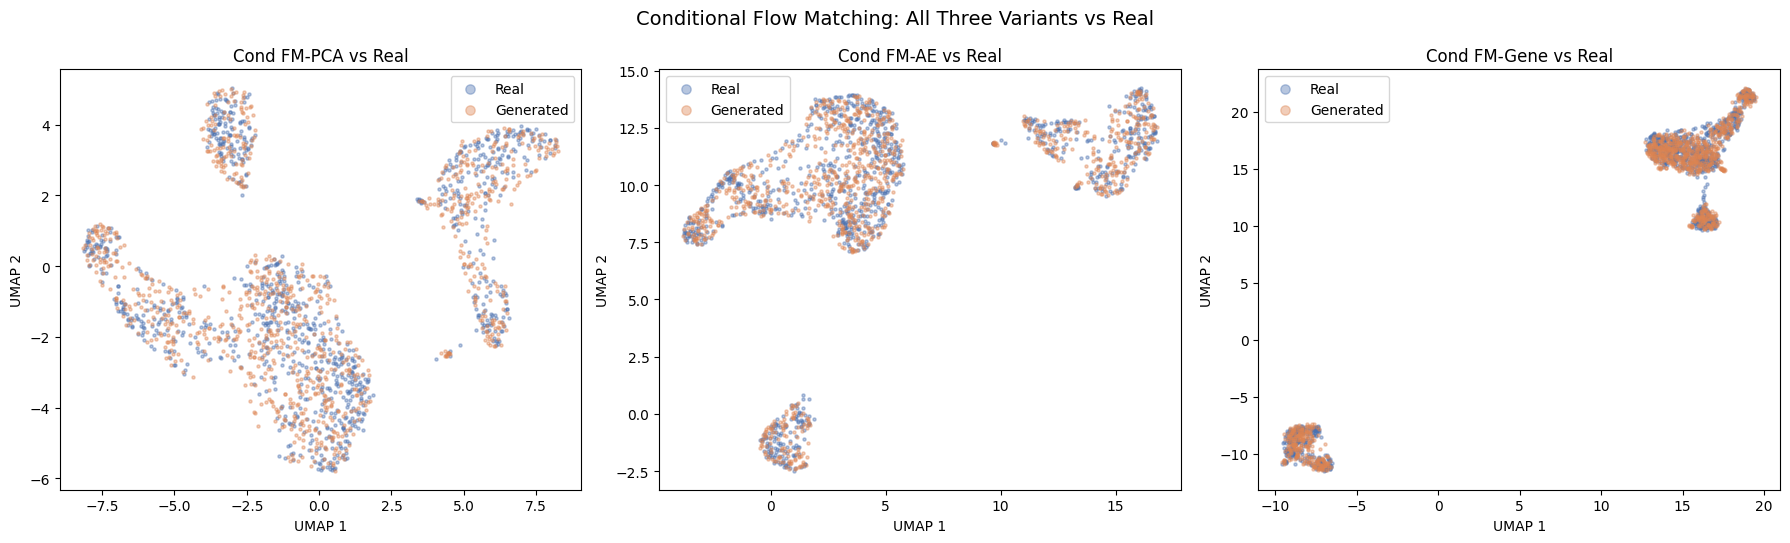

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
for ax, (X_gen, title) in zip(axes, [
    (X_gen_cond_pca, "Cond FM-PCA vs Real"),
    (X_gen_cond_ae, "Cond FM-AE vs Real"),
    (X_gen_cond_gene, "Cond FM-Gene vs Real"),
]):
    plot_umap_overlay(X_all, X_gen, title=title, ax=ax)
fig.suptitle("Conditional Flow Matching: All Three Variants vs Real", fontsize=14)
plt.tight_layout()
plt.show()

## 6. Save All Results

In [ ]:
os.makedirs(cfg.MODEL_DIR, exist_ok=True)

# Models
torch.save(cond_flow_pca.state_dict(), os.path.join(cfg.MODEL_DIR, "flow_cond_pca.pt"))
torch.save(cond_flow_ae.state_dict(), os.path.join(cfg.MODEL_DIR, "flow_cond_ae.pt"))
torch.save(cond_flow_gene.state_dict(), os.path.join(cfg.MODEL_DIR, "flow_cond_gene.pt"))

# Generated data
np.save(os.path.join(cfg.DATA_DIR, "X_gen_cond_pca.npy"), X_gen_cond_pca)
np.save(os.path.join(cfg.DATA_DIR, "X_gen_cond_ae.npy"), X_gen_cond_ae)
np.save(os.path.join(cfg.DATA_DIR, "X_gen_cond_gene.npy"), X_gen_cond_gene)

# Labels
np.save(os.path.join(cfg.DATA_DIR, "labels_gen_cond_pca.npy"), labels_gen_pca)
np.save(os.path.join(cfg.DATA_DIR, "labels_gen_cond_ae.npy"), labels_gen_ae)
np.save(os.path.join(cfg.DATA_DIR, "labels_gen_cond_gene.npy"), labels_gen_gene)

print("Saved all 3 conditional FM models and generated data.")

Saved all 3 conditional FM models and generated data.


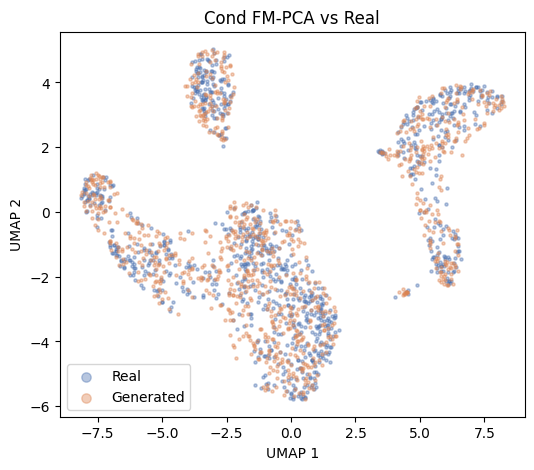

Saved cond_fm_pca_umap.png


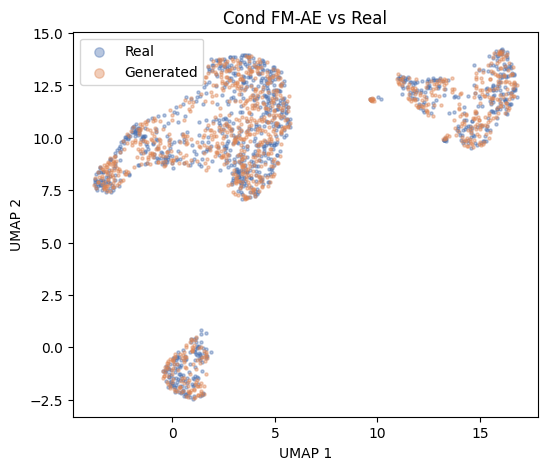

Saved cond_fm_ae_umap.png


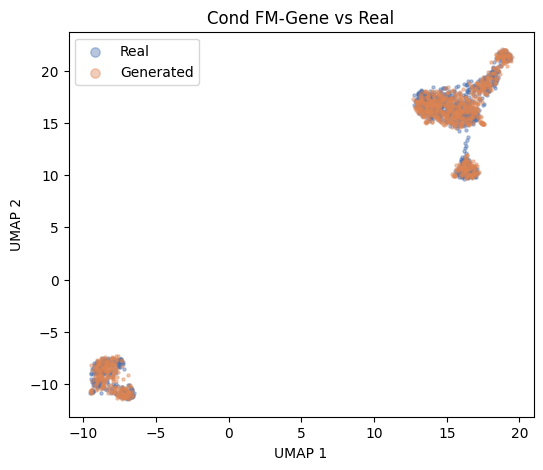

Saved cond_fm_gene_umap.png


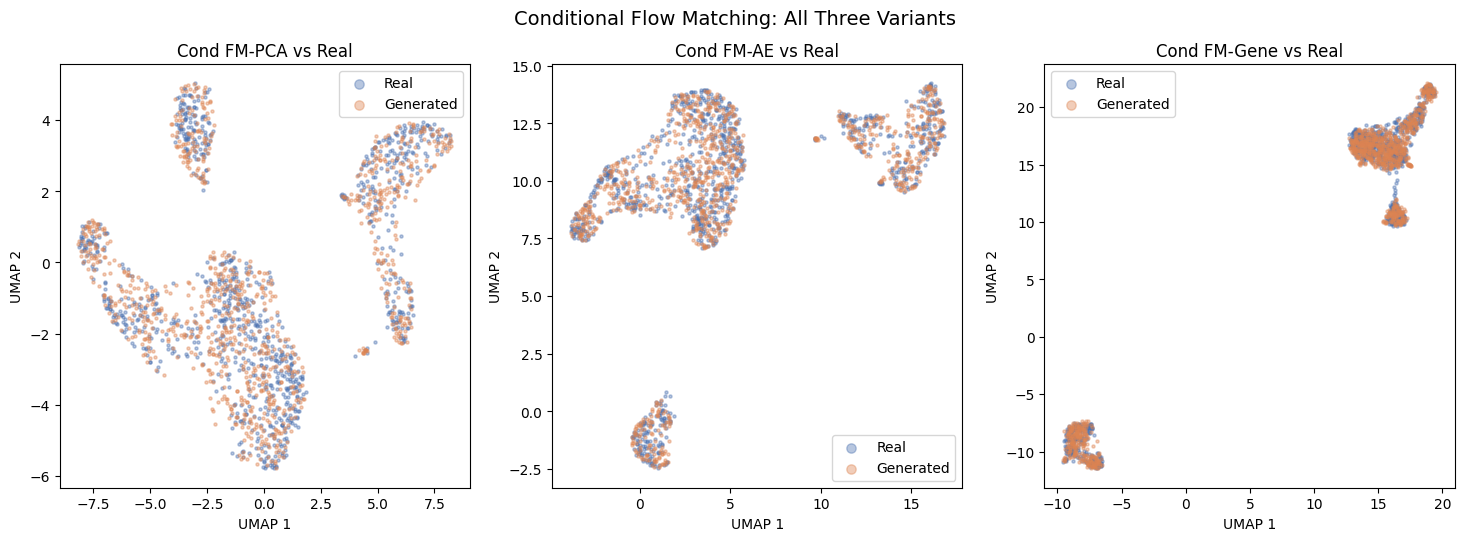

Saved cond_fm_comparison_umap.png

All plots saved to /home/zhuoyuan/CSprojects/GenAI_SingleCell/artifacts/figures


In [ ]:
# %% Save all plots to artifacts/figures/
import os, sys                                                                                                                          
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))                                                                         
sys.path.insert(0, PROJECT_ROOT)                                                                                                        
os.chdir(PROJECT_ROOT)                                                                                                                  
                                                                                                                                        
import numpy as np                                                                                                                      
import matplotlib                                                                                                                       
import matplotlib.pyplot as plt                                                                                                         
import config as cfg                                                                                                                    
from src.preprocess import set_seed, load_processed                                                                                     
from src.metrics import distribution_metrics, compute_mmd, memorization_check, plot_umap_overlay
                                            
set_seed()                                                                                                                              
os.makedirs(cfg.FIGURE_DIR, exist_ok=True)                                                                                              
                                                                                                                                        
# Load real data                                                                                                                        
data = load_processed()                                                                                                                 
X_all = data["X_all"]                                                                                                                   
labels_all = np.load(os.path.join(cfg.DATA_DIR, "leiden_labels.npy"))                                                                 
                                            
# Load all conditional generated data (already saved from the run above)                                                                
X_gen_cond_pca = np.load(os.path.join(cfg.DATA_DIR, "X_gen_cond_pca.npy"))
X_gen_cond_ae = np.load(os.path.join(cfg.DATA_DIR, "X_gen_cond_ae.npy"))                                                                
X_gen_cond_gene = np.load(os.path.join(cfg.DATA_DIR, "X_gen_cond_gene.npy"))                                                            
labels_gen_pca = np.load(os.path.join(cfg.DATA_DIR, "labels_gen_cond_pca.npy"))                                                         
labels_gen_ae = np.load(os.path.join(cfg.DATA_DIR, "labels_gen_cond_ae.npy"))                                                           
labels_gen_gene = np.load(os.path.join(cfg.DATA_DIR, "labels_gen_cond_gene.npy"))                                                       
                                                                                                                                        
# Individual UMAPs                                                                                                                      
for X_gen, name, fname in [                                                                                                             
    (X_gen_cond_pca, "Cond FM-PCA vs Real", "cond_fm_pca_umap.png"),                                                                    
    (X_gen_cond_ae, "Cond FM-AE vs Real", "cond_fm_ae_umap.png"),                                                                       
    (X_gen_cond_gene, "Cond FM-Gene vs Real", "cond_fm_gene_umap.png"),                                                                 
]:                                                                                                                                      
    fig, ax = plt.subplots(figsize=(6, 5))                                                                                              
    plot_umap_overlay(X_all, X_gen, title=name, ax=ax)                                                                                  
    fig.savefig(os.path.join(cfg.FIGURE_DIR, fname), dpi=150, bbox_inches="tight")                                                      
    plt.show()                                                   
    print(f"Saved {fname}")                                                                                                             
                                                                
# Side-by-side comparison                                                                                                               
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))                
for ax, (X_gen, title) in zip(axes, [                                                                                                   
    (X_gen_cond_pca, "Cond FM-PCA"),                             
    (X_gen_cond_ae, "Cond FM-AE"),                                                                                                      
    (X_gen_cond_gene, "Cond FM-Gene"),                                                                                                  
]):
    plot_umap_overlay(X_all, X_gen, title=title + " vs Real", ax=ax)                                                                    
fig.suptitle("Conditional Flow Matching: All Three Variants", fontsize=14)
fig.savefig(os.path.join(cfg.FIGURE_DIR, "cond_fm_comparison_umap.png"), dpi=150, bbox_inches="tight")                                  
plt.show()                                                       
print("Saved cond_fm_comparison_umap.png")                                                                                              
                                                                                                                                        
print(f"\nAll plots saved to {cfg.FIGURE_DIR}")